# Model Training
**CareGuard — Hospital Readmission Risk Prediction**

This notebook trains and evaluates three classification models to predict 30-day hospital readmission, then saves the best model for use in the backend API.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score, roc_curve

import joblib
import shap

shap.initjs()

## Step 1 — Load Data
Read the processed feature set and separate features (`X`) from the binary target (`y`).

In [2]:
df = pd.read_csv('../data/processed/features.csv')

X = df.drop(columns=['readmitted_30'])
y = df['readmitted_30']

print(f'Features shape: {X.shape}')
print(f'Target distribution:\n{y.value_counts()}')
print(f'Positive rate: {y.mean():.2%}')

Features shape: (99492, 32)
Target distribution:
readmitted_30
0    88323
1    11169
Name: count, dtype: int64
Positive rate: 11.23%


## Step 2 — Train / Test Split
Split 80/20 with stratification to preserve the class ratio in both sets.

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train size: {X_train.shape[0]:,}  |  Test size: {X_test.shape[0]:,}')
print(f'Train positive rate: {y_train.mean():.2%}')
print(f'Test  positive rate: {y_test.mean():.2%}')

Train size: 79,593  |  Test size: 19,899
Train positive rate: 11.23%
Test  positive rate: 11.23%


## Step 3 — Handle Class Imbalance
The dataset is imbalanced (few readmissions < 30 days). We address this by:
- Passing `class_weight='balanced'` to sklearn models, which adjusts sample weights inversely proportional to class frequency.
- Using `scale_pos_weight` in XGBoost, which is the ratio of negatives to positives.

In [4]:
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale_pos_weight = neg / pos

print(f'Negatives: {neg:,}  |  Positives: {pos:,}')
print(f'scale_pos_weight for XGBoost: {scale_pos_weight:.2f}')

Negatives: 70,658  |  Positives: 8,935
scale_pos_weight for XGBoost: 7.91


## Step 4 — Train Three Models
Train Logistic Regression, Random Forest, and XGBoost. Each model is fitted on the training set.

In [5]:
# Logistic Regression
lr = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
lr.fit(X_train, y_train)
print('Logistic Regression trained')

Logistic Regression trained


In [6]:
# Random Forest
rf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
print('Random Forest trained')

Random Forest trained


In [7]:
# XGBoost
xgb = XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    n_estimators=100,
    random_state=42,
    eval_metric='logloss',
    use_label_encoder=False
)
xgb.fit(X_train, y_train)
print('XGBoost trained')

XGBoost trained


## Step 5 — Evaluate All Three Models
For each model, print the full classification report and ROC-AUC score on the held-out test set.

In [8]:
models = {
    'Logistic Regression': lr,
    'Random Forest':       rf,
    'XGBoost':             xgb
}

results = {}

for name, model in models.items():
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, y_prob)
    results[name] = {'auc': auc, 'y_prob': y_prob}

    print(f'\n{"-"*50}')
    print(f'{name}')
    print(f'ROC-AUC: {auc:.4f}')
    print(classification_report(y_test, y_pred, target_names=['Not Readmitted', 'Readmitted <30d']))


--------------------------------------------------
Logistic Regression
ROC-AUC: 0.6356
                 precision    recall  f1-score   support

 Not Readmitted       0.92      0.69      0.79     17665
Readmitted <30d       0.17      0.50      0.25      2234

       accuracy                           0.67     19899
      macro avg       0.54      0.59      0.52     19899
   weighted avg       0.83      0.67      0.73     19899


--------------------------------------------------
Random Forest
ROC-AUC: 0.6248
                 precision    recall  f1-score   support

 Not Readmitted       0.89      1.00      0.94     17665
Readmitted <30d       0.39      0.01      0.02      2234

       accuracy                           0.89     19899
      macro avg       0.64      0.50      0.48     19899
   weighted avg       0.83      0.89      0.84     19899


--------------------------------------------------
XGBoost
ROC-AUC: 0.6447
                 precision    recall  f1-score   support

 Not R

## Step 6 — ROC Curves
Plot all three ROC curves on the same chart for visual comparison.

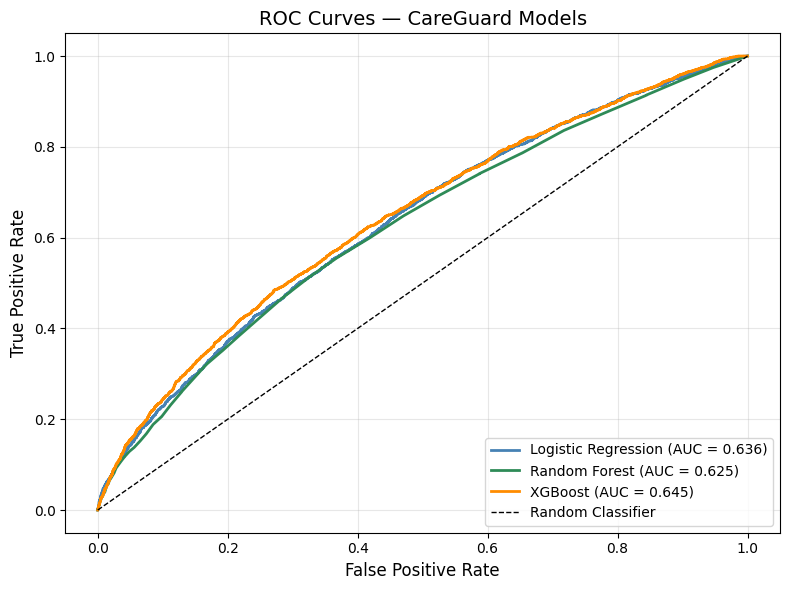

ROC curve saved to data/processed/roc_curves.png


In [9]:
fig, ax = plt.subplots(figsize=(8, 6))

colors = {'Logistic Regression': 'steelblue', 'Random Forest': 'seagreen', 'XGBoost': 'darkorange'}

for name, res in results.items():
    fpr, tpr, _ = roc_curve(y_test, res['y_prob'])
    ax.plot(fpr, tpr, label=f"{name} (AUC = {res['auc']:.3f})", color=colors[name], lw=2)

ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random Classifier')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves — CareGuard Models', fontsize=14)
ax.legend(loc='lower right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../data/processed/roc_curves.png', dpi=150)
plt.show()
print('ROC curve saved to data/processed/roc_curves.png')

## Step 7 — Feature Importance (Best Model)
Plot the top 20 most important features from the best-performing tree-based model (Random Forest or XGBoost, whichever has higher AUC).

Best model: XGBoost (AUC = 0.6447)


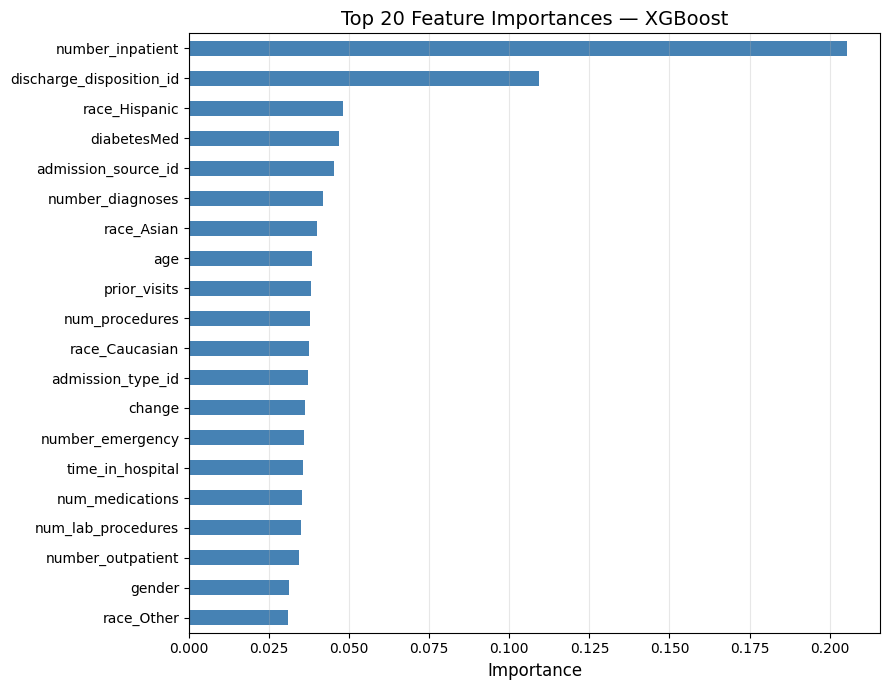

Feature importance plot saved to data/processed/feature_importance.png


In [10]:
best_name = max(results, key=lambda k: results[k]['auc'])
best_model = models[best_name]
print(f'Best model: {best_name} (AUC = {results[best_name]["auc"]:.4f})')

importances = pd.Series(best_model.feature_importances_, index=X.columns)
top20 = importances.nlargest(20).sort_values()

fig, ax = plt.subplots(figsize=(9, 7))
top20.plot(kind='barh', ax=ax, color='steelblue')
ax.set_title(f'Top 20 Feature Importances — {best_name}', fontsize=14)
ax.set_xlabel('Importance', fontsize=12)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('../data/processed/feature_importance.png', dpi=150)
plt.show()
print('Feature importance plot saved to data/processed/feature_importance.png')

## Step 8 — SHAP Values
Use SHAP (SHapley Additive exPlanations) to explain individual predictions from the best model. We compute SHAP values on a random sample of 500 test rows for efficiency.

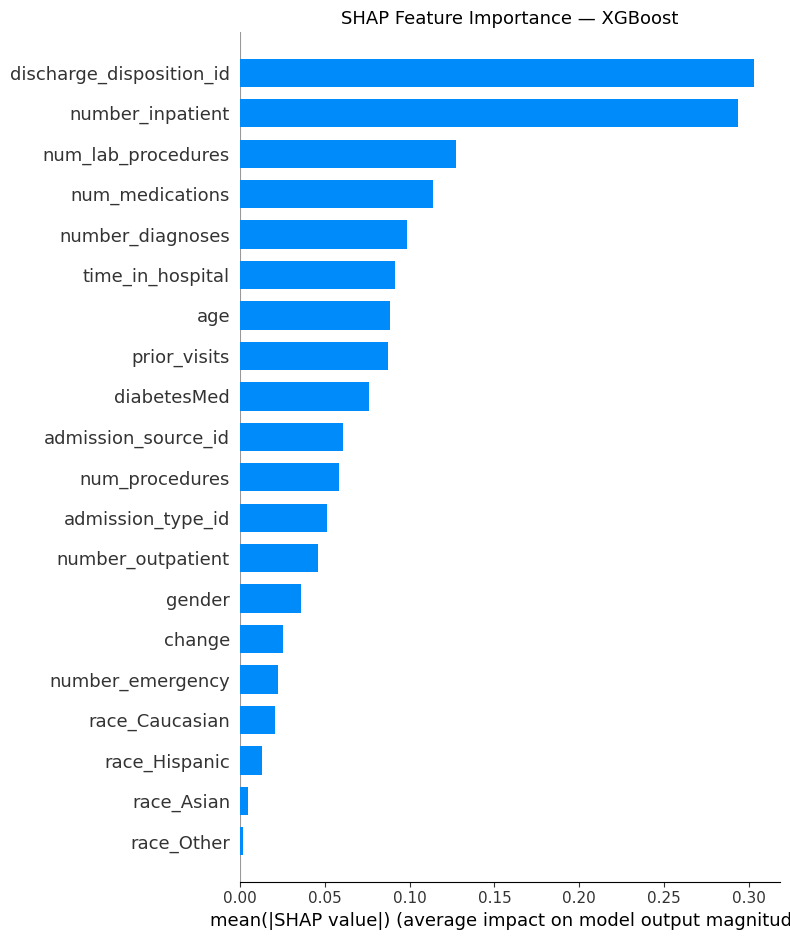

SHAP summary plot saved to data/processed/shap_summary.png


In [11]:
sample = X_test.sample(500, random_state=42)

explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(sample)

# For binary classifiers shap_values may be a list [class0, class1]
if isinstance(shap_values, list):
    sv = shap_values[1]
else:
    sv = shap_values

plt.figure()
shap.summary_plot(sv, sample, plot_type='bar', show=False, max_display=20)
plt.title(f'SHAP Feature Importance — {best_name}', fontsize=13)
plt.tight_layout()
plt.savefig('../data/processed/shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print('SHAP summary plot saved to data/processed/shap_summary.png')

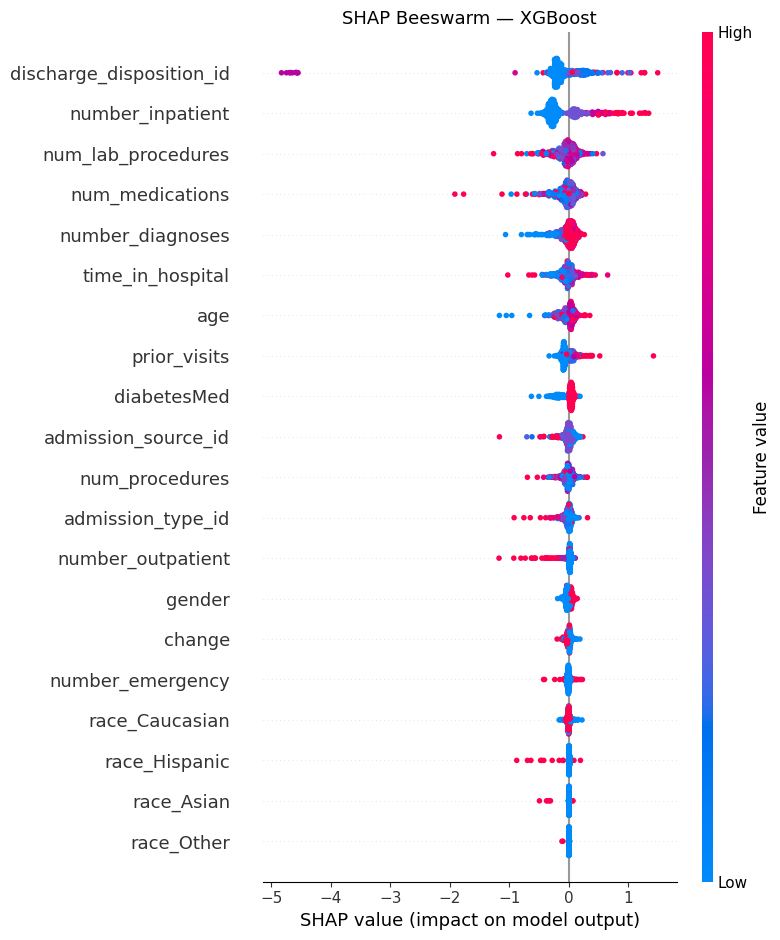

SHAP beeswarm plot saved to data/processed/shap_beeswarm.png


In [12]:
# Beeswarm plot showing direction of impact
plt.figure()
shap.summary_plot(sv, sample, show=False, max_display=20)
plt.title(f'SHAP Beeswarm — {best_name}', fontsize=13)
plt.tight_layout()
plt.savefig('../data/processed/shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()
print('SHAP beeswarm plot saved to data/processed/shap_beeswarm.png')

## Step 9 — Save Best Model
Persist the best model to `backend/model.pkl` using `joblib` for use by the FastAPI backend.

In [13]:
model_path = '../backend/model.pkl'
joblib.dump(best_model, model_path)
print(f'Best model ({best_name}) saved to {model_path}')

Best model (XGBoost) saved to ../backend/model.pkl


## Step 10 — Final Summary
Compare all three models side by side.

In [14]:
from sklearn.metrics import precision_score, recall_score, f1_score

summary_rows = []
for name, model in models.items():
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    summary_rows.append({
        'Model':     name,
        'ROC-AUC':   round(roc_auc_score(y_test, y_prob), 4),
        'Precision': round(precision_score(y_test, y_pred), 4),
        'Recall':    round(recall_score(y_test, y_pred), 4),
        'F1':        round(f1_score(y_test, y_pred), 4),
    })

summary_df = pd.DataFrame(summary_rows).set_index('Model')
print('\n=== Model Comparison ===')
print(summary_df.to_string())
print(f'\nBest model: {best_name}')
summary_df


=== Model Comparison ===
                     ROC-AUC  Precision  Recall      F1
Model                                                  
Logistic Regression   0.6356     0.1694  0.4991  0.2530
Random Forest         0.6248     0.3906  0.0112  0.0218
XGBoost               0.6447     0.1757  0.5090  0.2613

Best model: XGBoost


,ROC-AUC,Precision,Recall,F1
Model,,,,
Logistic Regression,0.6356,0.1694,0.4991,0.2530
Random Forest,0.6248,0.3906,0.0112,0.0218
XGBoost,0.6447,0.1757,0.5090,0.2613
